필요한거 import 

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from matplotlib.ticker import FuncFormatter

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1200)

# -------------------------
# 발표/PPT용 시각화 공통 설정
# -------------------------
font_path = r'C:\Windows\Fonts\malgun.ttf'
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
else:
    # Windows 외 환경에서도 노트북이 실행되도록 fallback
    font_name = 'DejaVu Sans'

# 교통수단별 고정 색상: PPT/Streamlit에서도 동일하게 사용
BICYCLE_COLOR = '#2E86AB'
SUBWAY_COLOR = '#F28E2B'
TEMP_COLOR = '#6C757D'
GRID_COLOR = '#D9D9D9'

sns.set_theme(style='whitegrid', context='notebook', font=font_name)
plt.rcParams.update({
    'font.family': font_name,
    'font.sans-serif': [font_name],
    'axes.unicode_minus': False,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = 'figures_ppt'
os.makedirs(FIG_DIR, exist_ok=True)

def style_ax(ax, title=None, xlabel=None, ylabel=None, y_grid=True):
    if title:
        ax.set_title(title, pad=14, loc='left')
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(axis='y' if y_grid else 'both', alpha=0.28, color=GRID_COLOR)
    if y_grid:
        ax.grid(axis='x', visible=False)
    ax.tick_params(axis='both', length=0)
    return ax

def save_fig(fig, filename):
    fig.savefig(os.path.join(FIG_DIR, filename), facecolor='white')

print('사용 폰트:', font_name)


사용 폰트: Malgun Gothic


데이터 로드 및 점검

In [2]:
# Windows 프로젝트 경로와 현재 노트북 단독 실행을 모두 지원
data_path_candidates = [
    r'data\processed\analysis_dataset.csv',
    os.path.join('data', 'processed', 'analysis_dataset.csv'),
    'analysis_dataset.csv'
]

data_path = next((p for p in data_path_candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        'analysis_dataset.csv를 찾지 못했습니다. '
        'data\\processed\\analysis_dataset.csv 또는 현재 폴더에 파일을 두세요.'
    )

df = pd.read_csv(data_path, encoding='utf-8-sig')
df['날짜'] = pd.to_datetime(df['날짜'])

print('데이터 경로:', data_path)
print('데이터 크기:', df.shape)
print('\n컬럼:')
print(df.columns.tolist())
print('\n데이터 타입:')
print(df.dtypes)
print('\n결측치:')
print(df.isna().sum())


데이터 경로: data\processed\analysis_dataset.csv
데이터 크기: (2196, 9)

컬럼:
['날짜', '시간대', '따릉이대여건수', '지하철승차인원', '기온(°C)', '요일', '요일명', '주말여부', '공휴일여부']

데이터 타입:
날짜         datetime64[us]
시간대                   str
따릉이대여건수             int64
지하철승차인원           float64
기온(°C)            float64
요일                  int64
요일명                   str
주말여부                 bool
공휴일여부                bool
dtype: object

결측치:
날짜         0
시간대        0
따릉이대여건수    0
지하철승차인원    0
기온(°C)     0
요일         0
요일명        0
주말여부       0
공휴일여부      0
dtype: int64


구조 확인

In [3]:
print('===== 날짜 범위 =====')
print(df['날짜'].min())
print(df['날짜'].max())

print('\n===== 시간대 =====')
print(df['시간대'].unique())

print('\n===== 요일 =====')
print(df['요일명'].value_counts())

print('\n===== 주말 =====')
print(df['주말여부'].value_counts())

print('\n===== 공휴일 =====')
print(df['공휴일여부'].value_counts())

===== 날짜 범위 =====
2025-03-01 00:00:00
2025-12-31 00:00:00

===== 시간대 =====
<StringArray>
['06-07', '07-08', '08-09', '09-10', '10-11', '11-12', '12-13', '13-14', '14-15', '15-16', '16-17', '17-18', '18-19', '19-20', '20-21', '21-22', '22-23', '23-24']
Length: 18, dtype: str

===== 요일 =====
요일명
월    360
일    324
화    324
토    306
수    306
목    288
금    288
Name: count, dtype: int64

===== 주말 =====
주말여부
False    1566
True      630
Name: count, dtype: int64

===== 공휴일 =====
공휴일여부
False    2106
True       90
Name: count, dtype: int64


key 중복 (날짜, 시간대 중복 체크)

In [4]:
key = ['날짜', '시간대']

print('\n===== 중복 key =====')
print(df.duplicated(key).sum())


===== 중복 key =====
0


평일+비공휴일에 대해서 처리 (이후는 여유 있으면)

In [5]:
analysis_df = df[
    (~df['주말여부']) &
    (~df['공휴일여부'])
].copy()

analysis_df = analysis_df.reset_index(drop=True)

print('전체 데이터:', len(df))
print('평일·비공휴일:', len(analysis_df))

전체 데이터: 2196
평일·비공휴일: 1494


월, 월명 추가해서 사용

In [6]:
month_name = {
    3: '3월',
    6: '6월',
    9: '9월',
    12: '12월'
}

analysis_df['월'] = analysis_df['날짜'].dt.month
analysis_df['월명'] = analysis_df['월'].map(month_name)

# 주요 지표들 통계값 (중요)

In [7]:
stats = analysis_df[
    ['기온(°C)', '따릉이대여건수', '지하철승차인원']
].describe()

stats

,기온(°C),따릉이대여건수,지하철승차인원
count,1494.000000,1494.000000,1494.000000
mean,14.674096,5933.419009,281945.211513
std,10.960095,3815.027594,132248.287337
min,-11.800000,102.000000,51115.000000
25%,4.400000,3391.250000,199355.500000
50%,17.900000,4964.500000,237287.000000
75%,24.000000,7695.750000,329742.000000
max,33.600000,19943.000000,632005.000000


왜도 확인 (데이터가 어느 방향에 몰려있는지)
- 평균과 중앙값 차이
- 극단값
- 분포 비대칭
- 정규화/로그변환 필요성

- # 둘 다 이용량이 출/퇴근 시간대에 집중된 형태

In [8]:
skewness = analysis_df[
    ['기온(°C)', '따릉이대여건수', '지하철승차인원']
].skew()

print('왜도:')
print(skewness)

왜도:
기온(°C)    -0.266867
따릉이대여건수    1.137745
지하철승차인원    0.889195
dtype: float64


기온 분포
- 특정 기온 구간에 해당되는 행 개수

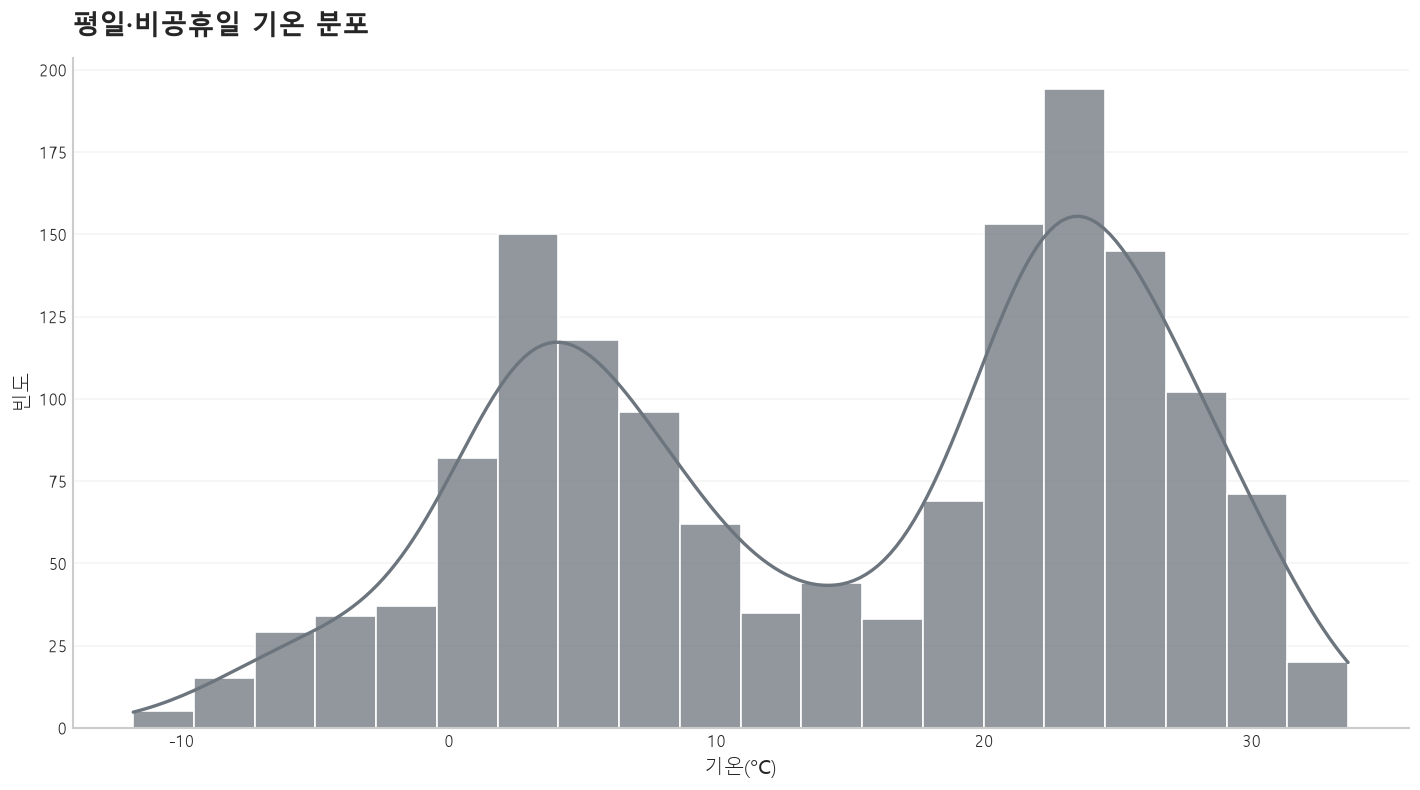

In [9]:
fig, ax = plt.subplots(figsize=(12, 6.75))
sns.histplot(data=analysis_df, x='기온(°C)', bins=20, kde=True,
             color=TEMP_COLOR, alpha=0.75, line_kws={'linewidth': 2}, ax=ax)
style_ax(ax, '평일·비공휴일 기온 분포', '기온(°C)', '빈도')
fig.tight_layout()
save_fig(fig, '01_temperature_distribution.png')
plt.show()


따릉이 분포
- 특정 대여건수 구간에 해당되는 행 개수

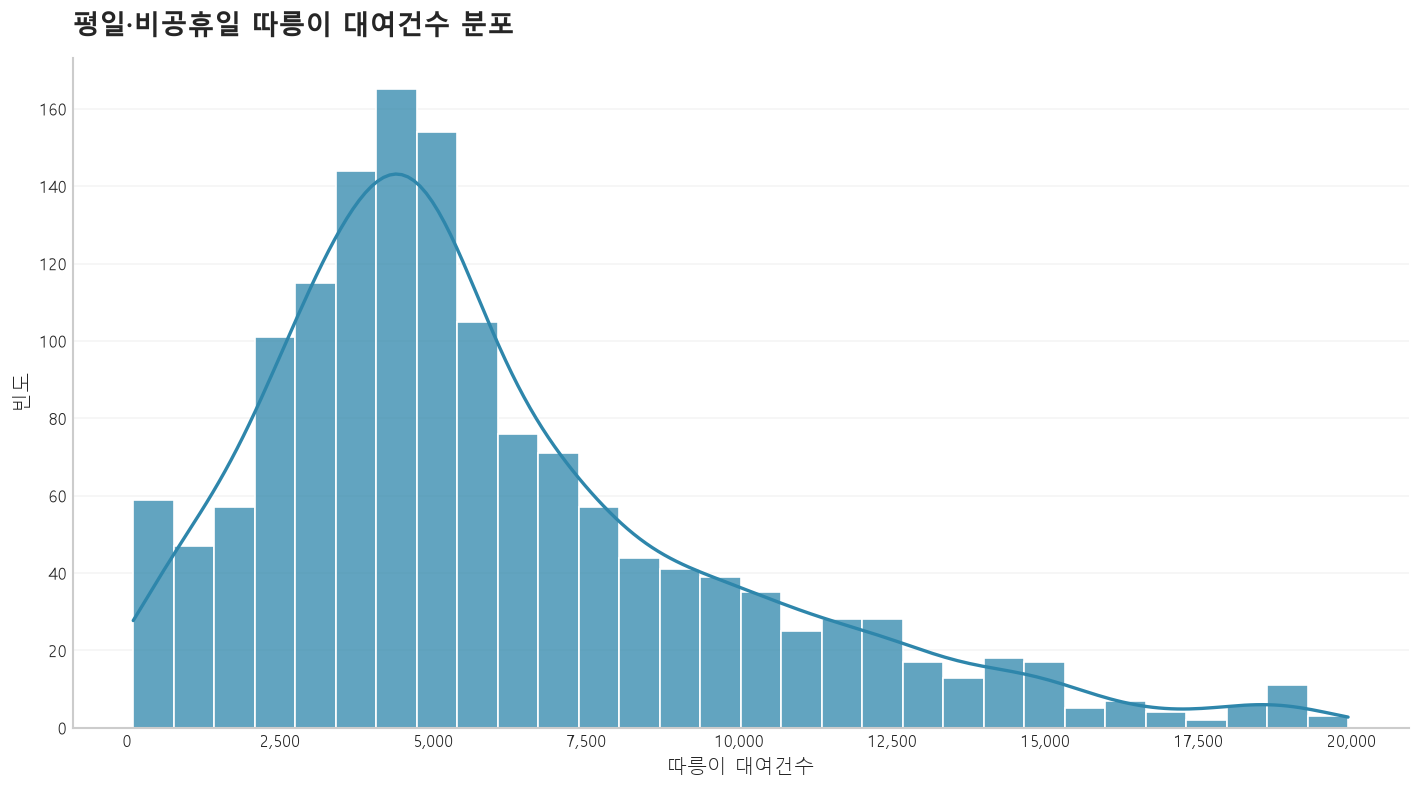

In [10]:
fig, ax = plt.subplots(figsize=(12, 6.75))
sns.histplot(data=analysis_df, x='따릉이대여건수', bins=30, kde=True,
             color=BICYCLE_COLOR, alpha=0.75, line_kws={'linewidth': 2}, ax=ax)
style_ax(ax, '평일·비공휴일 따릉이 대여건수 분포', '따릉이 대여건수', '빈도')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '02_bicycle_distribution.png')
plt.show()


지하철 분포
- 특정 승차건수 구간에 해당되는 행 개수

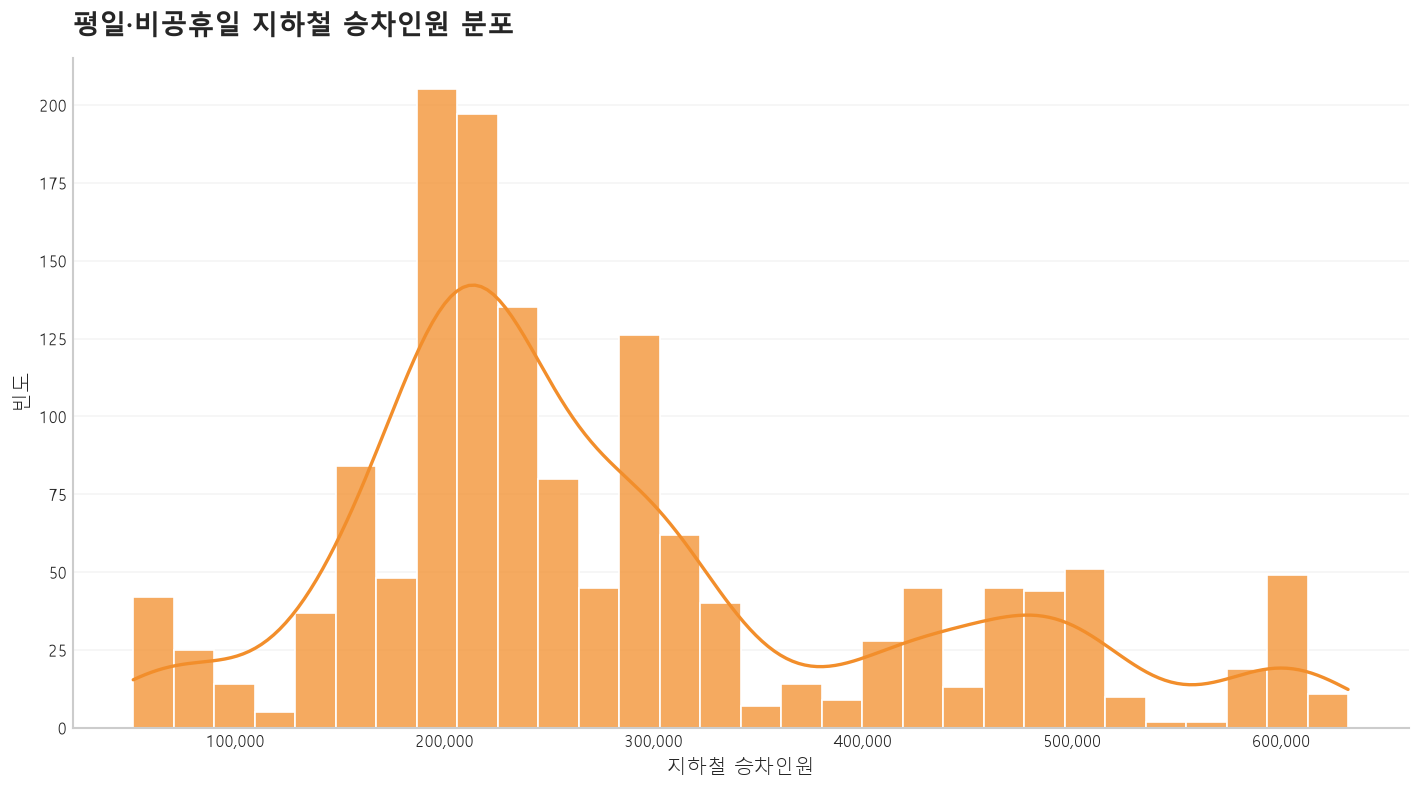

In [11]:
fig, ax = plt.subplots(figsize=(12, 6.75))
sns.histplot(data=analysis_df, x='지하철승차인원', bins=30, kde=True,
             color=SUBWAY_COLOR, alpha=0.75, line_kws={'linewidth': 2}, ax=ax)
style_ax(ax, '평일·비공휴일 지하철 승차인원 분포', '지하철 승차인원', '빈도')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '03_subway_distribution.png')
plt.show()


월별 기본 통계
- 3,6,9,12월 평균 기온과 대여건수, 승차건수

In [12]:
monthly = (
    analysis_df
    .groupby(['월', '월명'])
    .agg(
        평균기온=('기온(°C)', 'mean'),
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean'),
        일수=('날짜', 'nunique')
    )
    .reset_index()
    .sort_values('월')
)

monthly

,월,월명,평균기온,평균따릉이,평균지하철,일수
0,3,3월,9.040833,5440.152778,283382.986111,20
1,6,6월,24.757895,7354.494152,278205.005848,19
2,9,9월,24.220202,7305.353535,280545.040404,22
3,12,12월,1.540404,3782.616162,285268.492424,22


월별 평균 기온

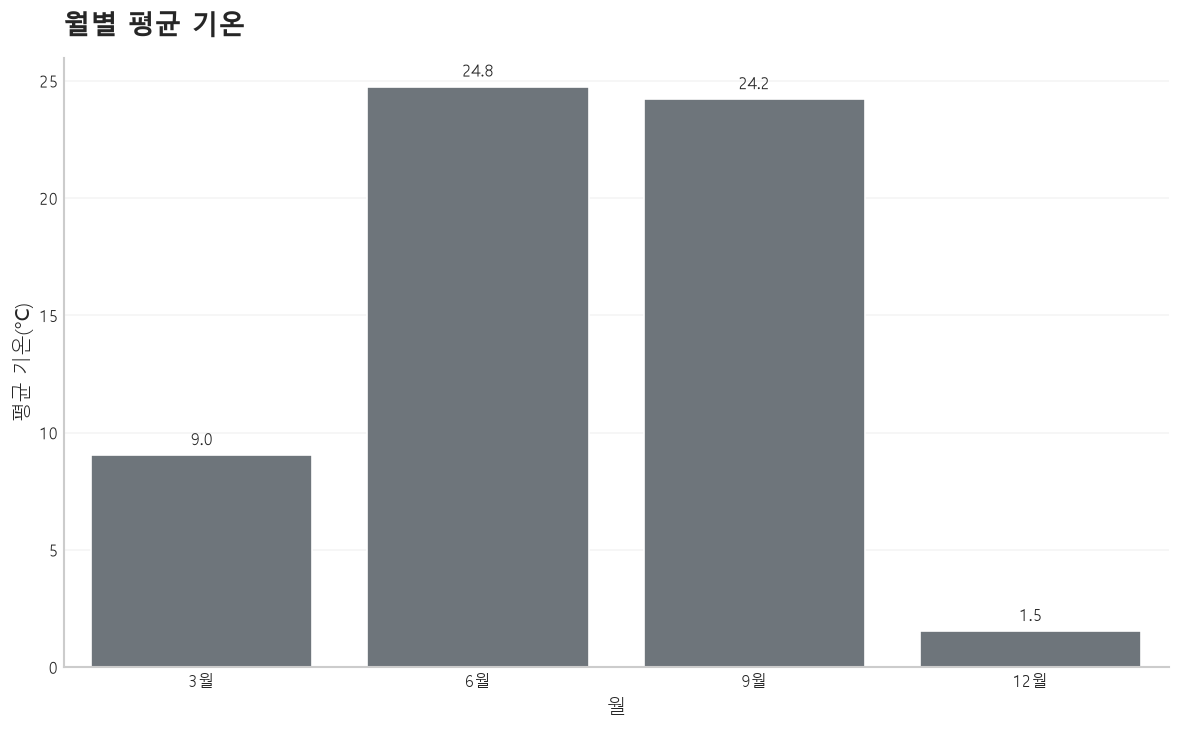

In [13]:
fig, ax = plt.subplots(figsize=(10, 6.25))
sns.barplot(data=monthly, x='월명', y='평균기온', color=TEMP_COLOR, ax=ax)
style_ax(ax, '월별 평균 기온', '월', '평균 기온(°C)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=4, fontsize=10)
fig.tight_layout()
save_fig(fig, '04_monthly_temperature.png')
plt.show()


월별 평균 따릉이
 - 이걸 바로 기온으로 묶으면 절대 안됨

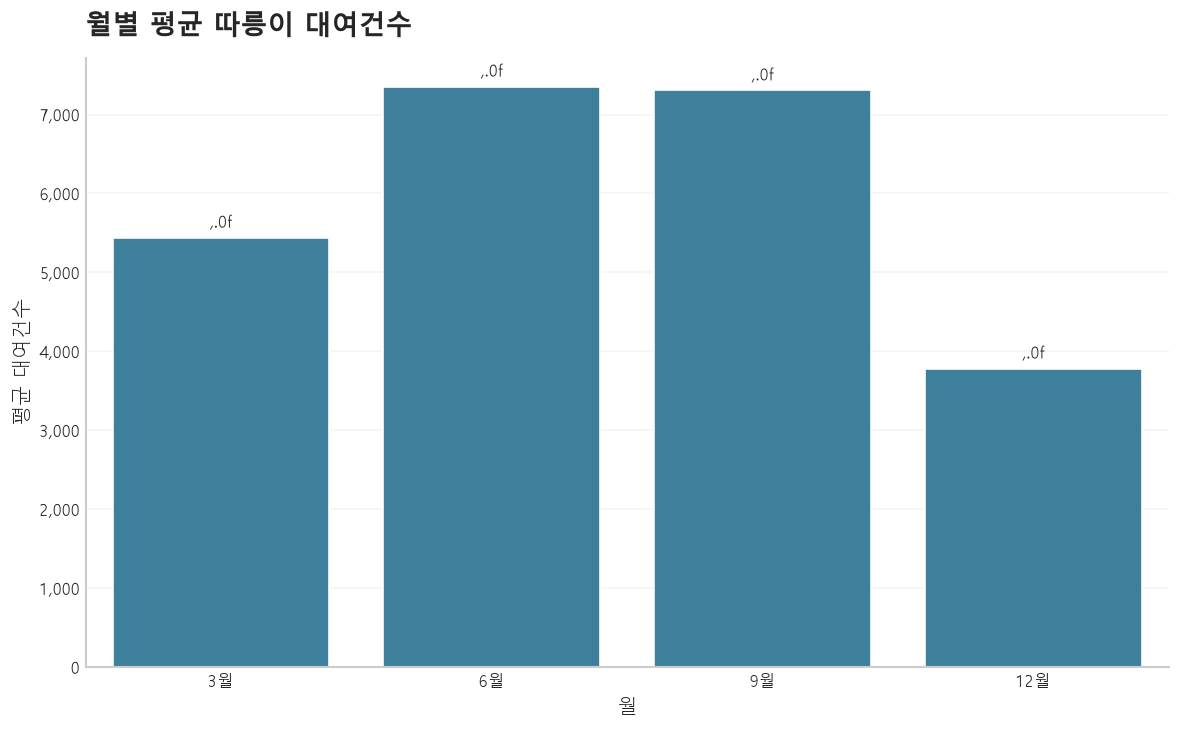

In [14]:
fig, ax = plt.subplots(figsize=(10, 6.25))
sns.barplot(data=monthly, x='월명', y='평균따릉이', color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '월별 평균 따릉이 대여건수', '월', '평균 대여건수')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
for container in ax.containers:
    ax.bar_label(container, fmt=',.0f', padding=4, fontsize=10)
fig.tight_layout()
save_fig(fig, '05_monthly_bicycle.png')
plt.show()


월별 평균 지하철
- 이걸 바로 기온으로 묶으면 절대 안됨

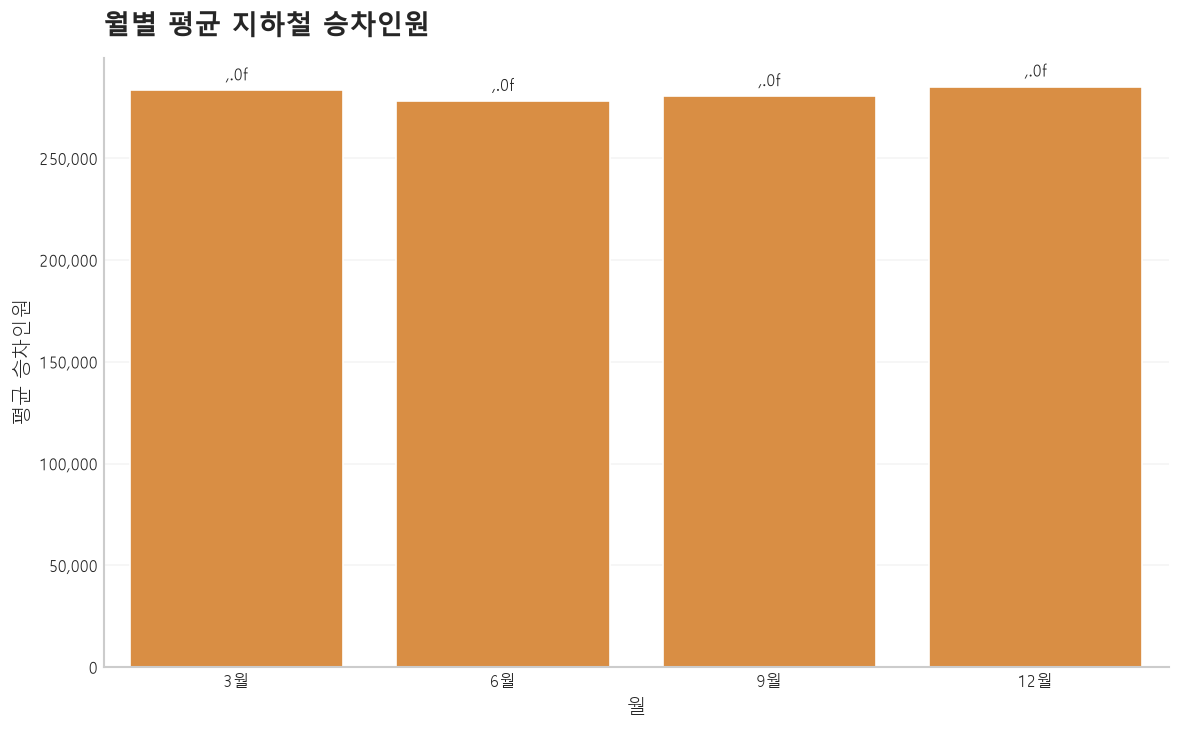

In [15]:
fig, ax = plt.subplots(figsize=(10, 6.25))
sns.barplot(data=monthly, x='월명', y='평균지하철', color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '월별 평균 지하철 승차인원', '월', '평균 승차인원')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
for container in ax.containers:
    ax.bar_label(container, fmt=',.0f', padding=4, fontsize=10)
fig.tight_layout()
save_fig(fig, '06_monthly_subway.png')
plt.show()


시간대별 평균 이용량
- 아무래도 출퇴근 시간에 집중

In [16]:
hour_order = [
    '06-07', '07-08', '08-09', '09-10',
    '10-11', '11-12', '12-13', '13-14',
    '14-15', '15-16', '16-17', '17-18',
    '18-19', '19-20', '20-21', '21-22',
    '22-23', '23-24'
]

hourly = (
    analysis_df
    .groupby('시간대')
    .agg(
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean')
    )
    .reindex(hour_order)
    .reset_index()
)

hourly

,시간대,평균따릉이,평균지하철
0,06-07,3192.819277,151077.506024
1,07-08,7889.686747,414058.228916
2,08-09,10904.879518,494632.253012
3,09-10,5210.542169,285343.759036
4,10-11,3542.578313,198217.530120
5,11-12,4053.867470,195427.963855
6,12-13,4230.421687,211058.192771
7,13-14,4073.566265,218959.650602
8,14-15,4142.301205,230050.373494
9,15-16,4885.469880,270526.036145


시간대별 따릉이 평균 이용량
- 출퇴근 시간에 얼마나 극단적인지 확인

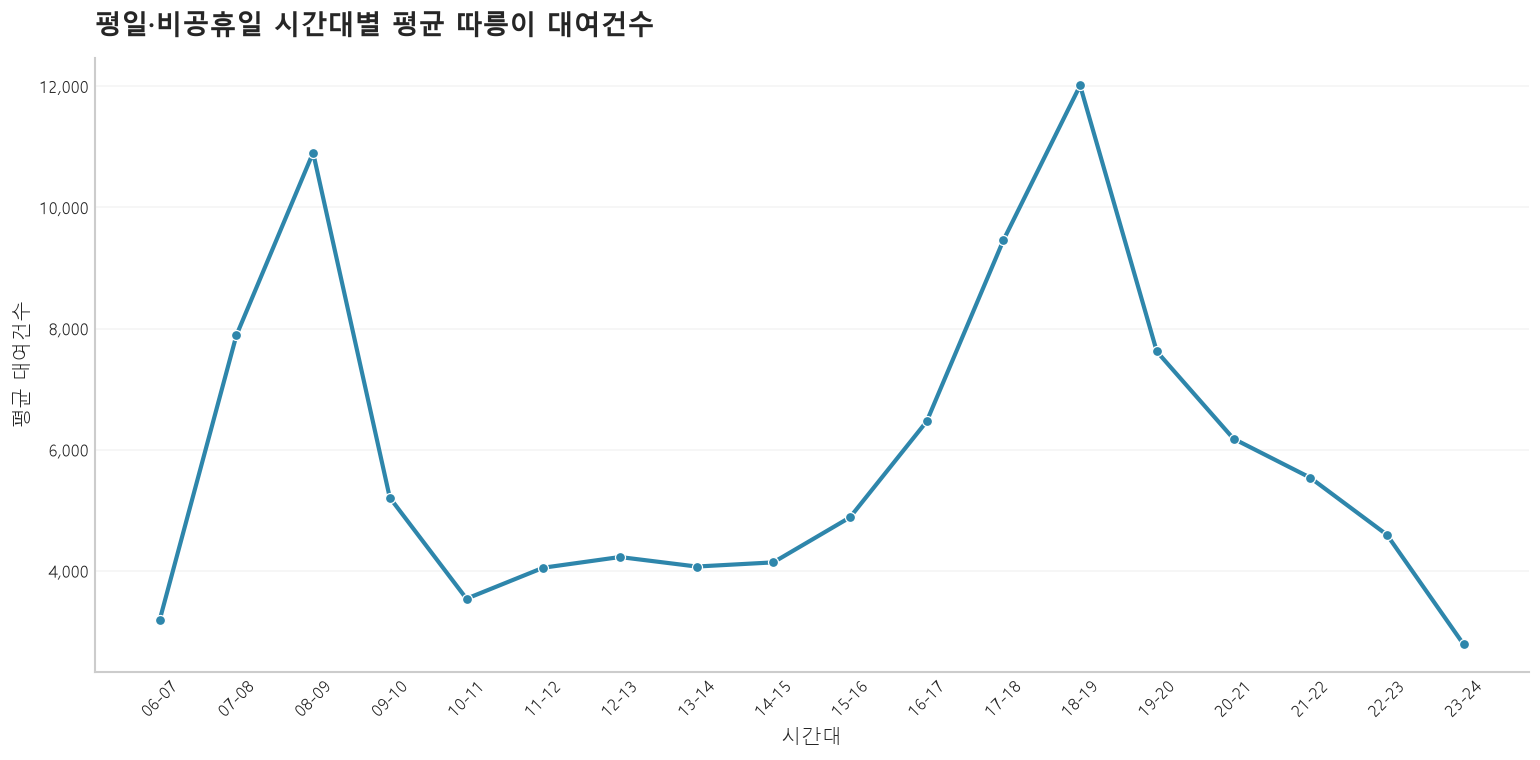

In [17]:
fig, ax = plt.subplots(figsize=(13, 6.5))
sns.lineplot(data=hourly, x='시간대', y='평균따릉이', marker='o', linewidth=2.5,
             markersize=6, color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '평일·비공휴일 시간대별 평균 따릉이 대여건수', '시간대', '평균 대여건수')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '07_hourly_bicycle.png')
plt.show()


시간대별 지하철 평균 이용량

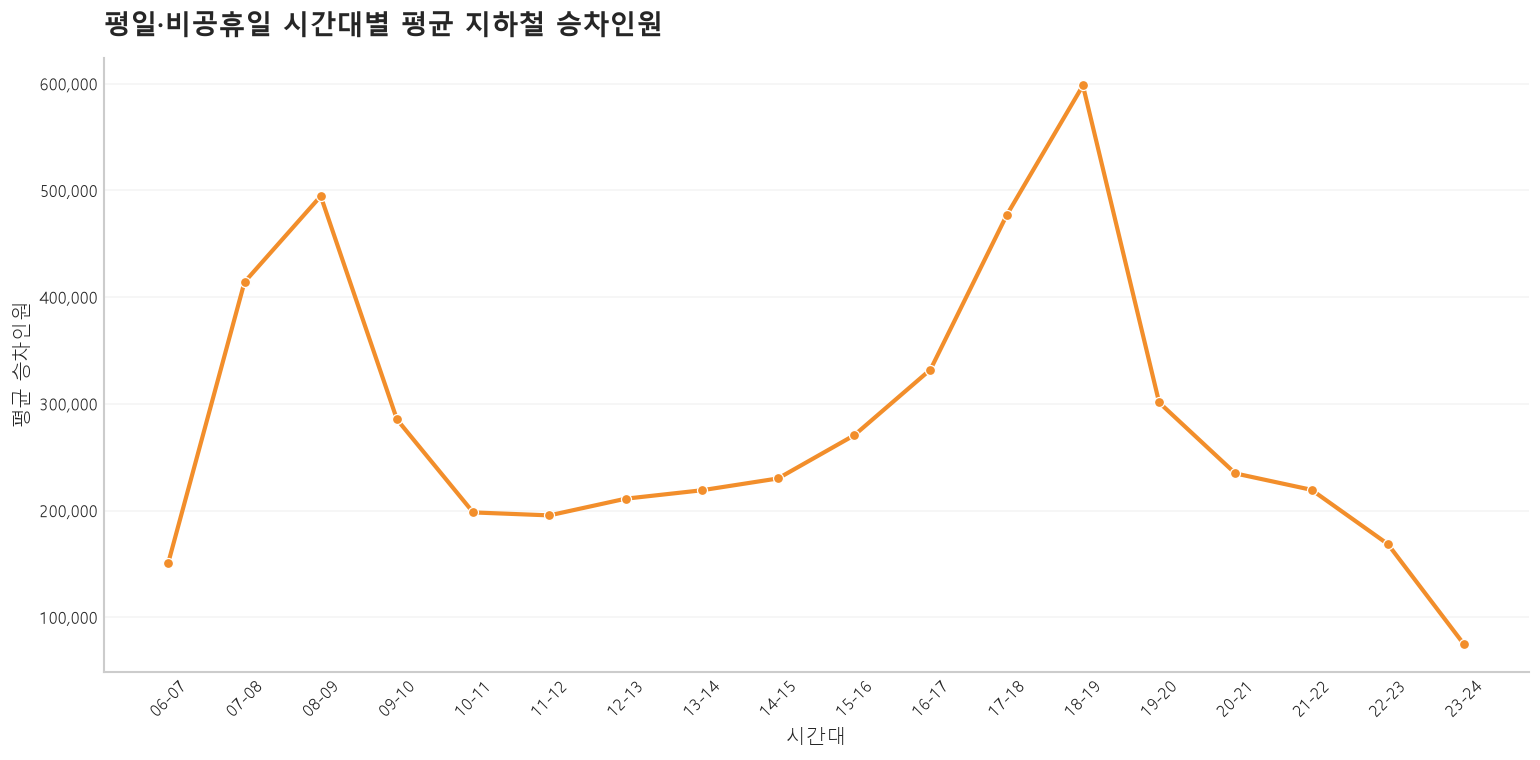

In [18]:
fig, ax = plt.subplots(figsize=(13, 6.5))
sns.lineplot(data=hourly, x='시간대', y='평균지하철', marker='o', linewidth=2.5,
             markersize=6, color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '평일·비공휴일 시간대별 평균 지하철 승차인원', '시간대', '평균 승차인원')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '08_hourly_subway.png')
plt.show()


시간대별 따릉이 지하철을 패턴을 정규화
- 평균=100 지수 만든다? 뭔말인지 찾아봐야겠음

In [19]:
hourly['따릉이지수'] = (
    hourly['평균따릉이'] /
    hourly['평균따릉이'].mean()
    * 100
)

hourly['지하철지수'] = (
    hourly['평균지하철'] /
    hourly['평균지하철'].mean()
    * 100
)

hourly

,시간대,평균따릉이,평균지하철,따릉이지수,지하철지수
0,06-07,3192.819277,151077.506024,53.810784,53.583994
1,07-08,7889.686747,414058.228916,132.970328,146.857691
2,08-09,10904.879518,494632.253012,183.787450,175.435593
3,09-10,5210.542169,285343.759036,87.816858,101.205393
4,10-11,3542.578313,198217.530120,59.705514,70.303563
5,11-12,4053.867470,195427.963855,68.322622,69.314163
6,12-13,4230.421687,211058.192771,71.298212,74.857875
7,13-14,4073.566265,218959.650602,68.654620,77.660354
8,14-15,4142.301205,230050.373494,69.813057,81.593999
9,15-16,4885.469880,270526.036145,82.338191,95.949860


따릉이 지하철 평균 대비 특정 시간대 이용량이 얼마나 다른지
- 아마 이게 스트림릿에 올라갈듯?

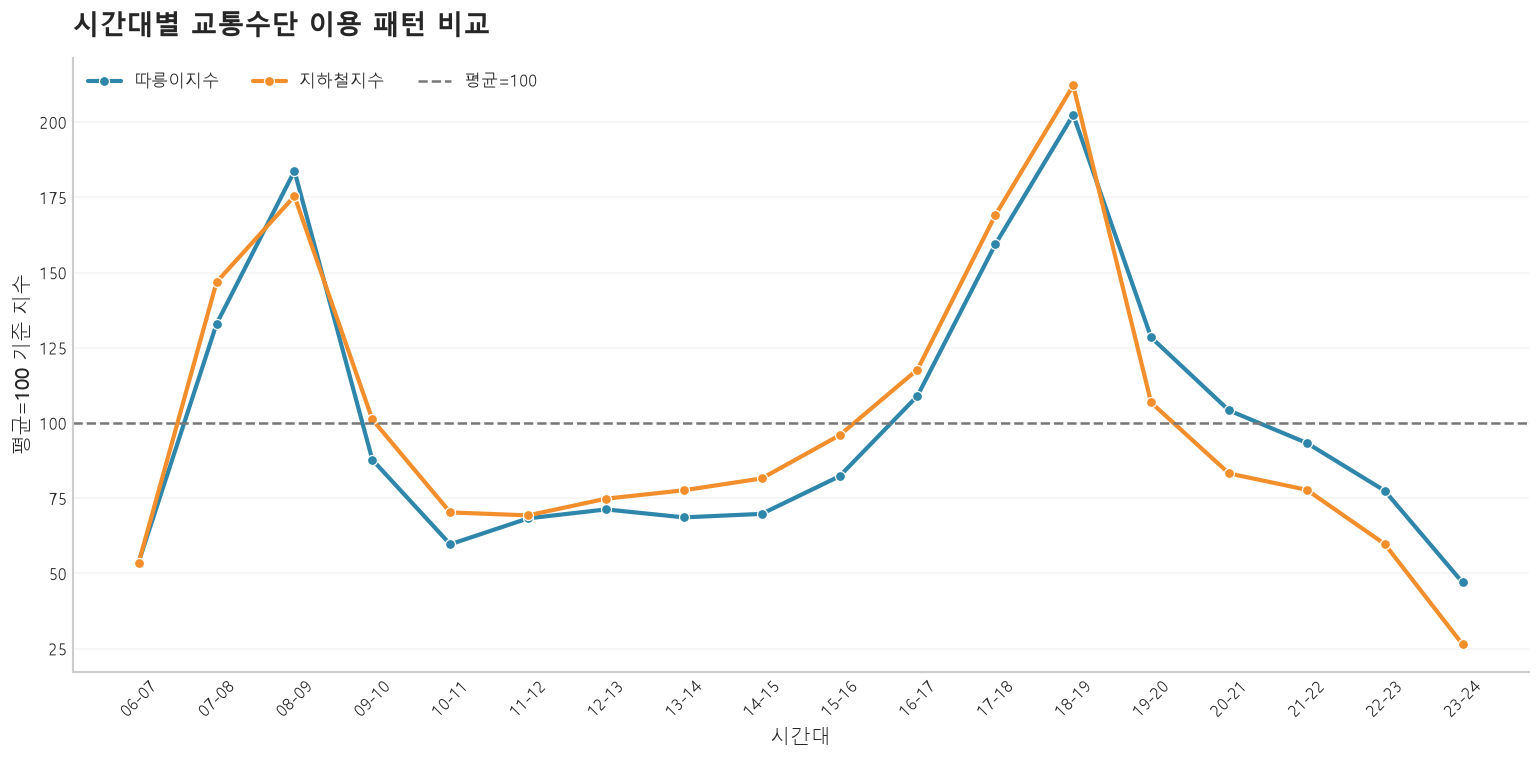

In [20]:
hourly_index = hourly[
    ['시간대', '따릉이지수', '지하철지수']
].melt(
    id_vars='시간대',
    var_name='교통수단',
    value_name='지수'
)

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.lineplot(data=hourly_index, x='시간대', y='지수', hue='교통수단',
             palette={'따릉이지수': BICYCLE_COLOR, '지하철지수': SUBWAY_COLOR},
             marker='o', linewidth=2.5, markersize=6, ax=ax)
ax.axhline(100, linestyle='--', linewidth=1.5, color='#777777', label='평균=100')
style_ax(ax, '시간대별 교통수단 이용 패턴 비교', '시간대', '평균=100 기준 지수')
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
save_fig(fig, '09_hourly_index_compare.png')
plt.show()


앞서서는 평일(주말,공휴일 제외) 했는데 이번엔 월~금

In [21]:
weekday_order = ['월', '화', '수', '목', '금']

weekday = (
    analysis_df
    .groupby('요일명')
    .agg(
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday

,요일명,평균따릉이,평균지하철
0,월,6452.160819,272911.435673
1,화,5880.676471,279832.045752
2,수,5573.336601,281437.666667
3,목,6524.755556,286507.111111
4,금,5152.877778,291796.233333


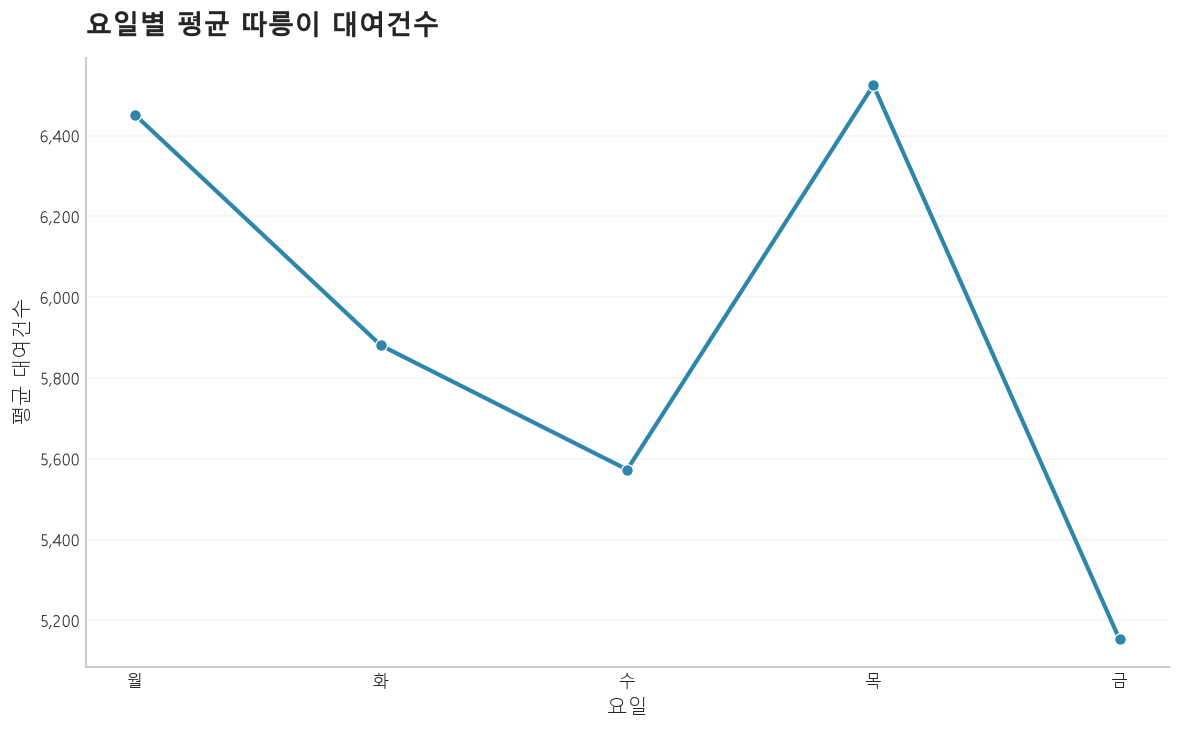

In [22]:
fig, ax = plt.subplots(figsize=(10, 6.25))
sns.lineplot(data=weekday, x='요일명', y='평균따릉이', marker='o', linewidth=2.5,
             markersize=7, color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '요일별 평균 따릉이 대여건수', '요일', '평균 대여건수')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '10_weekday_bicycle.png')
plt.show()


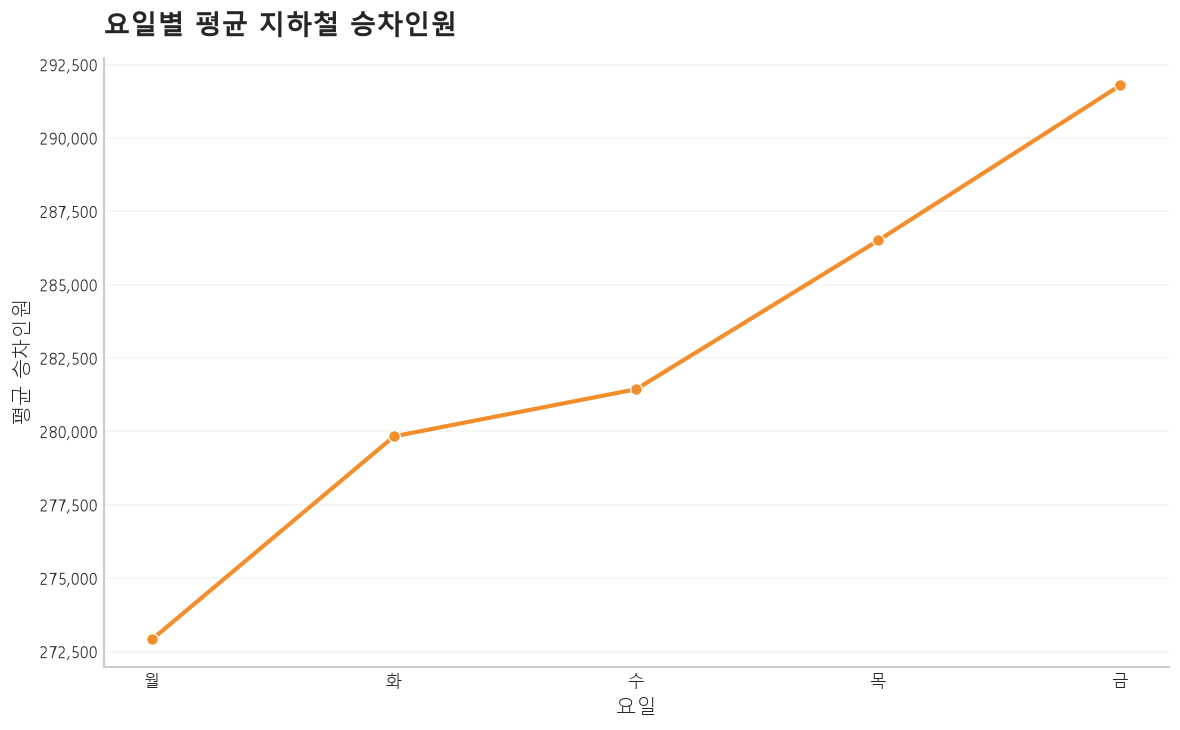

In [23]:
fig, ax = plt.subplots(figsize=(10, 6.25))
sns.lineplot(data=weekday, x='요일명', y='평균지하철', marker='o', linewidth=2.5,
             markersize=7, color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '요일별 평균 지하철 승차인원', '요일', '평균 승차인원')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '11_weekday_subway.png')
plt.show()


상관계수 : pearson + Spearman
- 여기부터 진짜 뭔소린지 모르겠음; 선형관계랑 단조로운 관계라는데 

In [24]:
target_cols = [
    '기온(°C)',
    '따릉이대여건수',
    '지하철승차인원'
]

pearson_corr = analysis_df[target_cols].corr(method='pearson')
spearman_corr = analysis_df[target_cols].corr(method='spearman')

print('===== Pearson =====')
print(pearson_corr)

print('\n===== Spearman =====')
print(spearman_corr)


===== Pearson =====
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.423440  0.012718
따릉이대여건수  0.423440  1.000000  0.652512
지하철승차인원  0.012718  0.652512  1.000000

===== Spearman =====
           기온(°C)   따릉이대여건수   지하철승차인원
기온(°C)   1.000000  0.462517  0.015601
따릉이대여건수  0.462517  1.000000  0.572017
지하철승차인원  0.015601  0.572017  1.000000


상관관계 히트맵
- 이건 ead용?

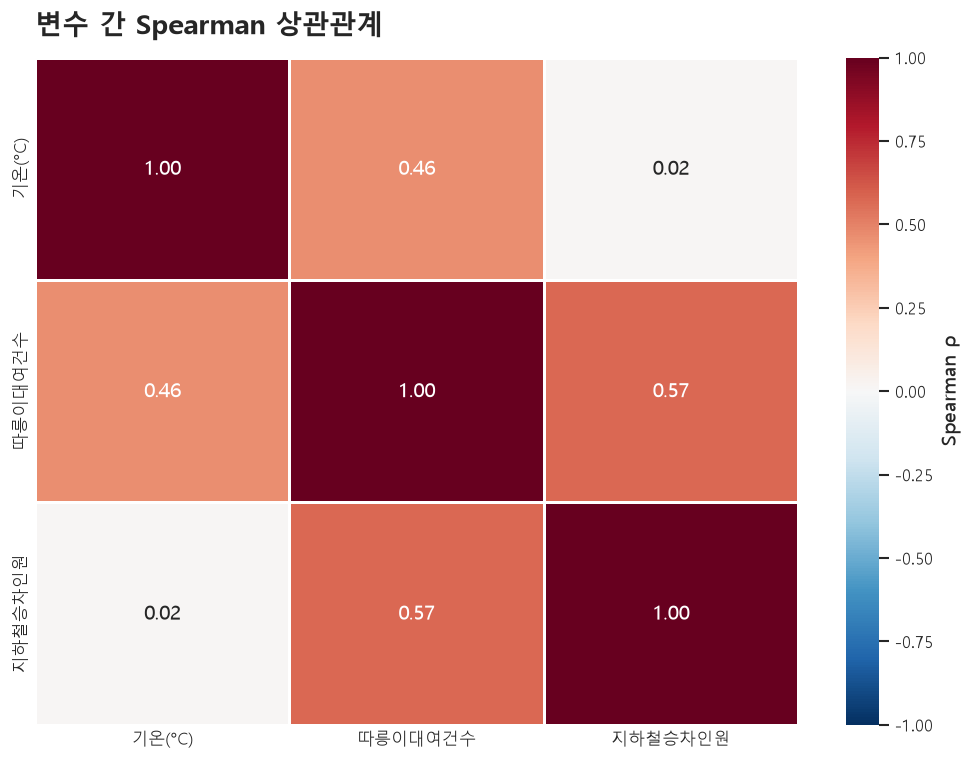

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.8, cbar_kws={'label': 'Spearman ρ'}, ax=ax)
style_ax(ax, '변수 간 Spearman 상관관계', None, None, y_grid=False)
fig.tight_layout()
save_fig(fig, '12_spearman_heatmap.png')
plt.show()


전체 기온 vs 따릉이
- 이걸 어떻게 vs 한다는거지

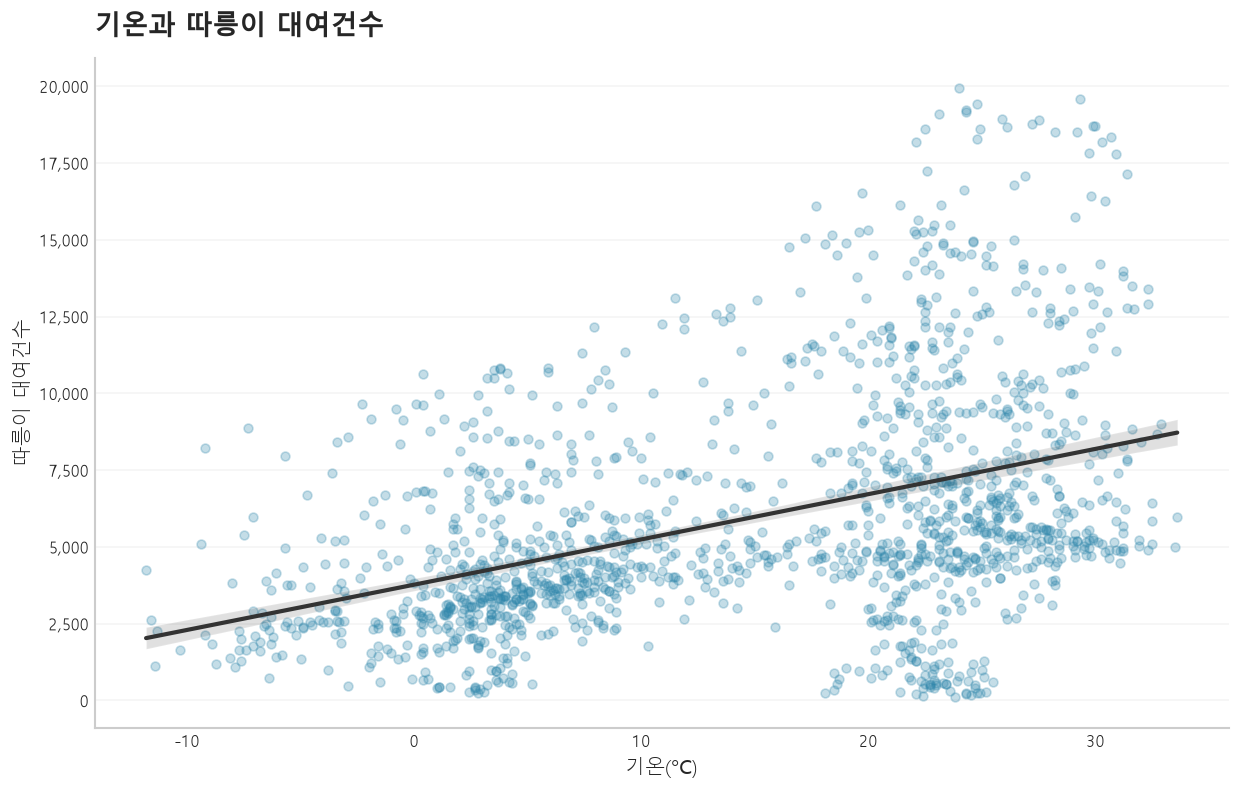

In [26]:
fig, ax = plt.subplots(figsize=(10.5, 6.75))
sns.regplot(data=analysis_df, x='기온(°C)', y='따릉이대여건수',
            scatter_kws={'alpha': 0.28, 's': 28, 'color': BICYCLE_COLOR},
            line_kws={'linewidth': 2.5, 'color': '#333333'}, ax=ax)
style_ax(ax, '기온과 따릉이 대여건수', '기온(°C)', '따릉이 대여건수')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '13_temperature_bicycle_reg.png')
plt.show()


전체 기온 vs 지하철

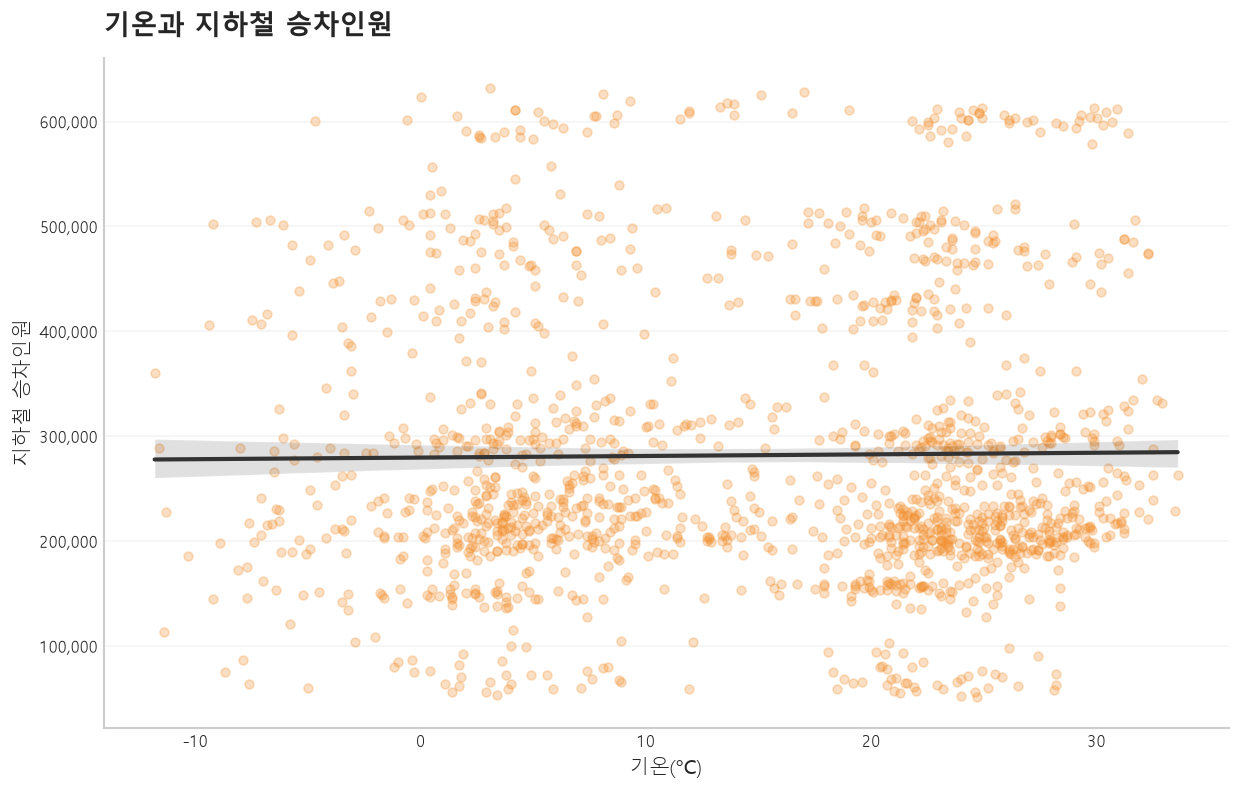

In [27]:
fig, ax = plt.subplots(figsize=(10.5, 6.75))
sns.regplot(data=analysis_df, x='기온(°C)', y='지하철승차인원',
            scatter_kws={'alpha': 0.28, 's': 28, 'color': SUBWAY_COLOR},
            line_kws={'linewidth': 2.5, 'color': '#333333'}, ax=ax)
style_ax(ax, '기온과 지하철 승차인원', '기온(°C)', '지하철 승차인원')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '14_temperature_subway_reg.png')
plt.show()


# 월별로 기온 관계 보기
- 3,12 / 6,9 묶어서 보라는데

In [ ]:
g = sns.lmplot(data=analysis_df, x='기온(°C)', y='따릉이대여건수',
                col='월명', col_order=['3월', '6월', '9월', '12월'], col_wrap=2,
                height=4.2, aspect=1.25,
                scatter_kws={'alpha': 0.25, 's': 24, 'color': BICYCLE_COLOR},
                line_kws={'linewidth': 2.2, 'color': '#333333'},
                facet_kws={'sharex': False, 'sharey': False})
g.set_axis_labels('기온(°C)', '따릉이 대여건수')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.grid(axis='y', alpha=0.25, color=GRID_COLOR)
    ax.grid(axis='x', visible=False)
    ax.tick_params(length=0)
g.figure.suptitle('월별 기온과 따릉이 대여건수 관계', y=1.02, fontsize=16, fontweight='bold', x=0.02, ha='left')
g.figure.tight_layout()
g.figure.savefig(os.path.join(FIG_DIR, '15_monthly_temperature_bicycle.png'), dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


# 핵심 : 시간대를 통제해서 기온 관계
- 시간이 같으면 이용 패턴이 같을텐데 여기서 달라지는건 기온 (물론 그 외에 날씨나 천재지변 등의 요인도 있음)
- 이 상관관계 값이 뚝 떨어진다 > 기온과 관계가 낮고, 이용량은 거진 시간대 영향이 엄청 큰것?

In [ ]:
within_hour = analysis_df.copy()

within_hour['기온편차'] = (
    within_hour['기온(°C)']
    - within_hour.groupby('시간대')['기온(°C)'].transform('mean')
)

within_hour['따릉이편차'] = (
    within_hour['따릉이대여건수']
    - within_hour.groupby('시간대')['따릉이대여건수'].transform('mean')
)

within_hour['지하철편차'] = (
    within_hour['지하철승차인원']
    - within_hour.groupby('시간대')['지하철승차인원'].transform('mean')
)

In [ ]:
print('===== 시간대 평균 제거 후 Pearson =====')

print(
    within_hour[
        ['기온편차', '따릉이편차', '지하철편차']
    ].corr(method='pearson')
)

print('\n===== 시간대 평균 제거 후 Spearman =====')

print(
    within_hour[
        ['기온편차', '따릉이편차', '지하철편차']
    ].corr(method='spearman')
)

# 특정 시간대에 기온관계가 강하게 나타나는지 확인
- 시간대별로 따릉이/지하철 기온 민감도 확인

In [ ]:
hour_corr = []

for hour, group in analysis_df.groupby('시간대', sort=False):
    hour_corr.append({
        '시간대': hour,
        '따릉이_Pearson': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='pearson'
        ),
        '따릉이_Spearman': group['기온(°C)'].corr(
            group['따릉이대여건수'],
            method='spearman'
        ),
        '지하철_Pearson': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='pearson'
        ),
        '지하철_Spearman': group['기온(°C)'].corr(
            group['지하철승차인원'],
            method='spearman'
        ),
        '관측수': len(group)
    })

hour_corr = pd.DataFrame(hour_corr)

hour_corr

In [ ]:
hour_corr_long = hour_corr[
    ['시간대', '따릉이_Spearman', '지하철_Spearman']
].melt(
    id_vars='시간대',
    var_name='교통수단',
    value_name='상관계수'
)

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.lineplot(data=hour_corr_long, x='시간대', y='상관계수', hue='교통수단',
             palette={'따릉이_Spearman': BICYCLE_COLOR, '지하철_Spearman': SUBWAY_COLOR},
             marker='o', linewidth=2.5, markersize=6, ax=ax)
ax.axhline(0, linestyle='--', linewidth=1.2, color='#777777')
style_ax(ax, '시간대별 기온-이용량 Spearman 상관계수', '시간대', 'Spearman ρ')
ax.set_ylim(-0.8, 0.8)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, '16_hourly_spearman.png')
plt.show()


# 그래서 특정 온도부터 따릉이 급증하거나 급락?
- 5도 단위로 구간화 (0도 미만~30도이상)

In [ ]:
bins = [
    -np.inf,
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    np.inf
]

labels = [
    '0℃ 미만',
    '0~5℃',
    '5~10℃',
    '10~15℃',
    '15~20℃',
    '20~25℃',
    '25~30℃',
    '30℃ 이상'
]

analysis_df['기온구간_탐색'] = pd.cut(
    analysis_df['기온(°C)'],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
temp_summary = (
    analysis_df
    .groupby('기온구간_탐색', observed=False)
    .agg(
        평균기온=('기온(°C)', 'mean'),
        평균따릉이=('따릉이대여건수', 'mean'),
        평균지하철=('지하철승차인원', 'mean'),
        관측수=('기온(°C)', 'size')
    )
    .reset_index()
)

temp_summary

따릉이 기온 구간별 이용량 그래프
- 관측수가 중요
- 30도 이상에서 급증하는듯 보이나, 관측수가 57건뿐

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.25))
sns.barplot(data=temp_summary, x='기온구간_탐색', y='평균따릉이', color=BICYCLE_COLOR, ax=ax)
style_ax(ax, '기온 구간별 평균 따릉이 대여건수', '기온 구간', '평균 대여건수')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
for container in ax.containers:
    ax.bar_label(container, fmt=',.0f', padding=4, fontsize=9)
fig.tight_layout()
save_fig(fig, '17_temperature_bin_bicycle.png')
plt.show()


지하철 기온 구간별 이용량 그래프

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.25))
sns.barplot(data=temp_summary, x='기온구간_탐색', y='평균지하철', color=SUBWAY_COLOR, ax=ax)
style_ax(ax, '기온 구간별 평균 지하철 승차인원', '기온 구간', '평균 승차인원')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
for container in ax.containers:
    ax.bar_label(container, fmt=',.0f', padding=4, fontsize=9)
fig.tight_layout()
save_fig(fig, '18_temperature_bin_subway.png')
plt.show()


기온 구간별 "상대지수"

In [ ]:
overall_bicycle_mean = analysis_df['따릉이대여건수'].mean()
overall_subway_mean = analysis_df['지하철승차인원'].mean()

temp_summary['따릉이지수'] = (
    temp_summary['평균따릉이']
    / overall_bicycle_mean
    * 100
)

temp_summary['지하철지수'] = (
    temp_summary['평균지하철']
    / overall_subway_mean
    * 100
)

temp_summary

# 이 그래프 중요
- 100 기준으로 평균대비 높고 낮은 구간
- KPI 후보
 

In [ ]:
temp_index = temp_summary[
    ['기온구간_탐색', '따릉이지수', '지하철지수']
].melt(
    id_vars='기온구간_탐색',
    var_name='교통수단',
    value_name='이용지수'
)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.lineplot(data=temp_index, x='기온구간_탐색', y='이용지수', hue='교통수단',
             palette={'따릉이지수': BICYCLE_COLOR, '지하철지수': SUBWAY_COLOR},
             marker='o', linewidth=2.5, markersize=7, ax=ax)
ax.axhline(100, linestyle='--', linewidth=1.5, color='#777777')
style_ax(ax, '기온 구간별 교통수단 이용지수', '기온 구간', '평균=100 기준 이용지수')
ax.tick_params(axis='x', rotation=35)
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, '19_temperature_index.png')
plt.show()


일별 데이터로 한번 더 확인

In [ ]:
daily = (
    analysis_df
    .groupby('날짜')
    .agg(
        평균기온=('기온(°C)', 'mean'),
        총따릉이=('따릉이대여건수', 'sum'),
        총지하철=('지하철승차인원', 'sum')
    )
    .reset_index()
)

daily.head()

기온 vs 일일 따릉이

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.75))
sns.regplot(data=daily, x='평균기온', y='총따릉이',
            scatter_kws={'alpha': 0.35, 's': 34, 'color': BICYCLE_COLOR},
            line_kws={'linewidth': 2.5, 'color': '#333333'}, ax=ax)
style_ax(ax, '일평균 기온과 일일 따릉이 대여량', '일평균 기온(°C)', '일일 총 대여건수')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '20_daily_temperature_bicycle.png')
plt.show()


기온 vs 일일 지하철

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.75))
sns.regplot(data=daily, x='평균기온', y='총지하철',
            scatter_kws={'alpha': 0.35, 's': 34, 'color': SUBWAY_COLOR},
            line_kws={'linewidth': 2.5, 'color': '#333333'}, ax=ax)
style_ax(ax, '일평균 기온과 일일 지하철 승차량', '일평균 기온(°C)', '일일 총 승차인원')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.tight_layout()
save_fig(fig, '21_daily_temperature_subway.png')
plt.show()


일별 상관관계

In [ ]:
print('===== 일별 Pearson =====')
print(
    daily[
        ['평균기온', '총따릉이', '총지하철']
    ].corr(method='pearson')
)

print('\n===== 일별 Spearman =====')
print(
    daily[
        ['평균기온', '총따릉이', '총지하철']
    ].corr(method='spearman')
)

# 월 x 시간대 히트맵
- 따릉이

In [ ]:
heat_bicycle = (
    analysis_df
    .pivot_table(
        index='월명', columns='시간대', values='따릉이대여건수',
        aggfunc='mean', observed=False
    )
    .reindex(index=['3월', '6월', '9월', '12월'], columns=hour_order)
)

fig, ax = plt.subplots(figsize=(15, 5.8))
sns.heatmap(heat_bicycle, annot=False, cmap='Blues', linewidths=0.4,
            cbar_kws={'label': '평균 대여건수'}, ax=ax)
style_ax(ax, '월별·시간대별 평균 따릉이 대여건수', '시간대', '월', y_grid=False)
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
save_fig(fig, '22_heatmap_bicycle.png')
plt.show()


- 지하철

In [ ]:
heat_subway = (
    analysis_df
    .pivot_table(
        index='월명', columns='시간대', values='지하철승차인원',
        aggfunc='mean', observed=False
    )
    .reindex(index=['3월', '6월', '9월', '12월'], columns=hour_order)
)

fig, ax = plt.subplots(figsize=(15, 5.8))
sns.heatmap(heat_subway, annot=False, cmap='Oranges', linewidths=0.4,
            cbar_kws={'label': '평균 승차인원'}, ax=ax)
style_ax(ax, '월별·시간대별 평균 지하철 승차인원', '시간대', '월', y_grid=False)
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
save_fig(fig, '23_heatmap_subway.png')
plt.show()


# 월별 상관계수
- 민감도가 계절별로 약하고 강하고 차이가 나면 까다로워짐?

In [ ]:
# 월별 상관: 각 월의 '평균기온'과 '평균 이용량'을 1개 관측치로 만든 뒤 4개월(3/6/9/12월)을 비교
monthly_corr_input = monthly[
    ['월', '월명', '평균기온', '평균따릉이', '평균지하철']
].copy()

month_corr = pd.DataFrame({
    '지표': ['따릉이', '지하철'],
    'Pearson': [
        monthly_corr_input['평균기온'].corr(monthly_corr_input['평균따릉이'], method='pearson'),
        monthly_corr_input['평균기온'].corr(monthly_corr_input['평균지하철'], method='pearson')
    ],
    'Spearman': [
        monthly_corr_input['평균기온'].corr(monthly_corr_input['평균따릉이'], method='spearman'),
        monthly_corr_input['평균기온'].corr(monthly_corr_input['평균지하철'], method='spearman')
    ],
    '관측수': [len(monthly_corr_input), len(monthly_corr_input)]
})

print('월별 상관 입력값:')
display(monthly_corr_input)
print('\n월별 Pearson/Spearman (n=4):')
display(month_corr)


## 발표용 핵심 해석 메모
- 전체 상관(1494행): 시간대별 이용량 차이가 섞인 관찰적 상관
- 일별 상관(83일): 날짜별 평균기온과 **일일 총 이용량**의 관계
- 시간대 통제: 각 시간대의 평균을 빼서 **같은 시간대에서 평소보다 얼마나 높은/낮은지** 비교
- 월별 상관: 월평균값 4개를 상관분석한 것이 아니라, 각 월 내부의 시간대별 관측값으로 계산
- 월+시간대 통제: 계절과 시간대의 평균 차이를 동시에 제거한 뒤 잔차 간 관계를 비교


# 핵심 요약

In [ ]:
print('==============================')
print('EDA 핵심 요약')
print('==============================')

print('\n[분석 데이터]')
print(f'전체 행: {len(df):,}')
print(f'평일·비공휴일: {len(analysis_df):,}')
print(f'날짜 수: {analysis_df["날짜"].nunique():,}')

print('\n[기온]')
print(analysis_df['기온(°C)'].describe())

print('\n[따릉이]')
print(analysis_df['따릉이대여건수'].describe())

print('\n[지하철]')
print(analysis_df['지하철승차인원'].describe())

print('\n[전체 상관 - Pearson]')
print(pearson_corr)

print('\n[전체 상관 - Spearman]')
print(spearman_corr)

print('\n[시간대 통제 후 Pearson]')
print(within_hour[['기온편차', '따릉이편차', '지하철편차']].corr(method='pearson'))

print('\n[시간대 통제 후 Spearman]')
print(within_hour[['기온편차', '따릉이편차', '지하철편차']].corr(method='spearman'))

print('\n[일별 상관]')
print(daily[['평균기온', '총따릉이', '총지하철']].corr(method='pearson'))
print(daily[['평균기온', '총따릉이', '총지하철']].corr(method='spearman'))

print('\n[월별 상관: 월평균값 4개]')
print(month_corr)


In [ ]:
group_keys = ['월', '시간대']

controlled = analysis_df.copy()

for col in ['기온(°C)', '따릉이대여건수', '지하철승차인원']:
    controlled[f'{col}_잔차'] = (
        controlled[col]
        - controlled.groupby(group_keys)[col].transform('mean')
    )

controlled_pearson = controlled[[
    '기온(°C)_잔차', '따릉이대여건수_잔차', '지하철승차인원_잔차'
]].corr(method='pearson')
controlled_spearman = controlled[[
    '기온(°C)_잔차', '따릉이대여건수_잔차', '지하철승차인원_잔차'
]].corr(method='spearman')

print('월×시간대 평균 제거 후 Pearson:')
print(controlled_pearson)

print('\n월×시간대 평균 제거 후 Spearman:')
print(controlled_spearman)
